In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


Part A: Data Understanding and Preprocessing

load dataset

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/ASSIGNMENT/ASSIGNMENT 8/weatherHistory.csv.zip")

In [ ]:
print(df.head(10))

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   

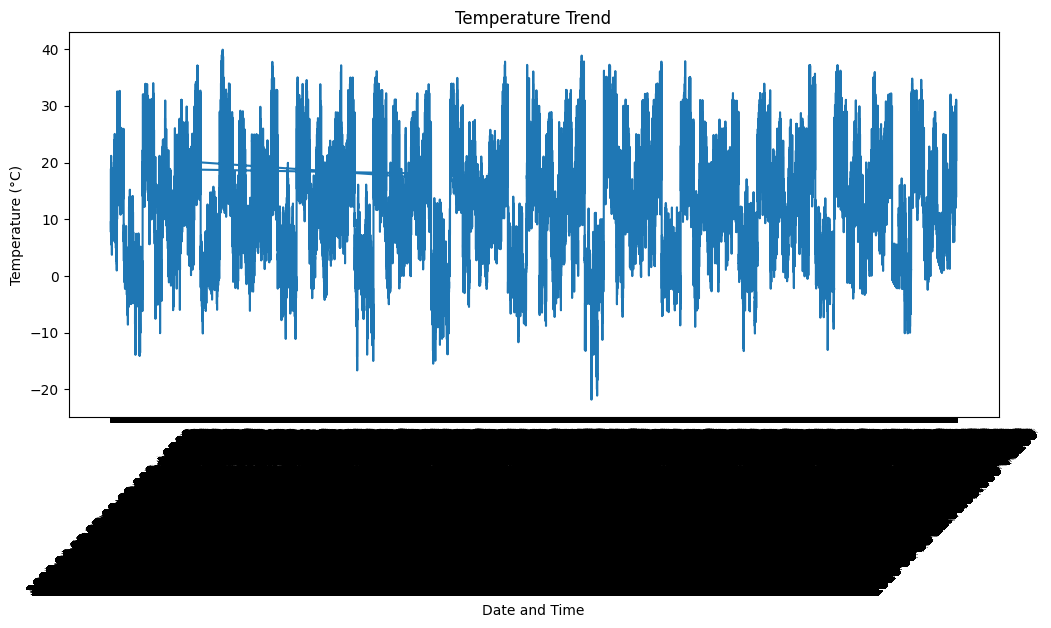

In [27]:
plt.figure(figsize=(12,5))
plt.plot(df["Formatted Date"], df["Temperature (C)"])
plt.title("Temperature Trend")
plt.xlabel("Date and Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#CONVERT DATE COLUM
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"],utc=True)
#extract the date only
df["Date"]=df["Formatted Date"].dt.date

In [ ]:
#convert the hourly data into the daily data
daily_df =df.groupby("Date")[
    [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)"
    ]
].mean().reset_index()
print(daily_df.head())

         Date  Temperature (C)  Humidity  Wind Speed (km/h)  \
0  2005-12-31         0.577778  0.890000          17.114300   
1  2006-01-01         4.075000  0.817083          21.229192   
2  2006-01-02         5.263194  0.847083          17.824713   
3  2006-01-03         2.340509  0.897083           7.726658   
4  2006-01-04         2.251852  0.906667          12.152817   

   Pressure (millibars)  
0           1016.660000  
1           1011.985000  
2           1010.384167  
3           1021.170833  
4            981.770833  


plot tempurature over time

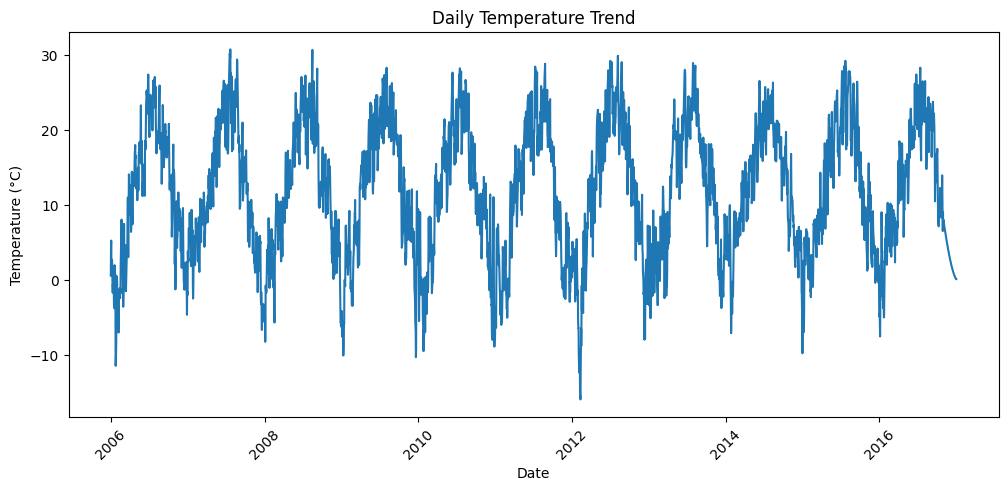

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_df["Date"], daily_df["Temperature (C)"])
plt.title("Daily Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#checking missing values
print(daily_df.isnull().sum())

Date                    0
Temperature (C)         0
Humidity                0
Wind Speed (km/h)       0
Pressure (millibars)    0
dtype: int64


2. Preprocess the data:

In [ ]:
#handling missing values
daily_df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_734/323922902.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df.fillna(method="ffill", inplace=True)


In [ ]:
#select featues
features=[
     "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)"
]
data =daily_df[features]

In [ ]:
#normalise
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

Create Input Sequences (Past 7 Days)

In [ ]:
sequence_length = 7

X = []
y = []

for i in range(len(scaled_data)-sequence_length):

    X.append(scaled_data[i:i+sequence_length])

    y.append(scaled_data[i+sequence_length,0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)


(4012, 7, 3)
(4012,)


split dataset


In [ ]:
train_size = int(0.70*len(X))
validation_size = int(0.15*len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_validation = X[train_size:train_size+validation_size]
y_validation = y[train_size:train_size+validation_size]

X_test = X[train_size+validation_size:]
y_test = y[train_size+validation_size:]

Build the SimpleRNN Model

In [ ]:
model = Sequential()

model.add(SimpleRNN(
    units=64,
    input_shape=(sequence_length,len(features))
))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_validation,y_validation),

    epochs=50,

    batch_size=32
)

Plot Training & Validation Loss

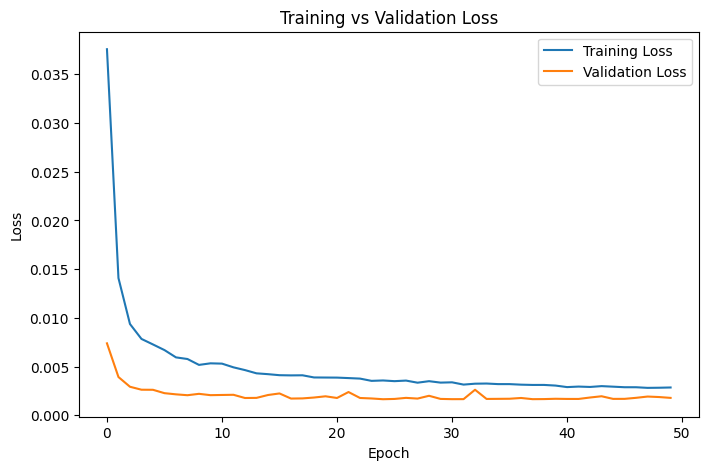

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

This graph compares the training loss and validation loss over 50 epochs. The training loss decreases steadily, which shows that the model is learning from the training data. The validation loss also remains low and stable, indicating that the model performs well on unseen data. Since there is no large gap between the two curves and the validation loss does not increase significantly, the model does not show signs of overfitting and has converged successfully

In [34]:
#Predict on Test Data
predictions = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [35]:
#Convert Predictions Back to Original Scale
dummy_pred = np.zeros((len(predictions),len(features)))

dummy_pred[:,0] = predictions.flatten()

predicted_temperature = scaler.inverse_transform(dummy_pred)[:,0]

dummy_actual = np.zeros((len(y_test),len(features)))

dummy_actual[:,0] = y_test

actual_temperature = scaler.inverse_transform(dummy_actual)[:,0]

part C: Model Evaluation & Forecasting

In [36]:
rmse = np.sqrt(mean_squared_error(actual_temperature,predicted_temperature))

mae = mean_absolute_error(actual_temperature,predicted_temperature)

r2 = r2_score(actual_temperature,predicted_temperature)

print("RMSE =",rmse)

print("MAE =",mae)

print("R2 Score =",r2)

RMSE = 2.0080753501944577
MAE = 1.557844593629405
R2 Score = 0.9436205982446741


The SimpleRNN model achieved an RMSE of 2.0081°C, indicating that the predicted temperatures differ from the actual temperatures by approximately 2°C on average. The MAE of 1.5578°C shows that the average absolute prediction error is relatively small. Furthermore, the model obtained an R² score of 0.9436, which means it explains approximately 94.36% of the variability in the daily temperature data. These results indicate that the model provides accurate and reliable temperature predictions.

Plot Actual vs Predicted Temperature

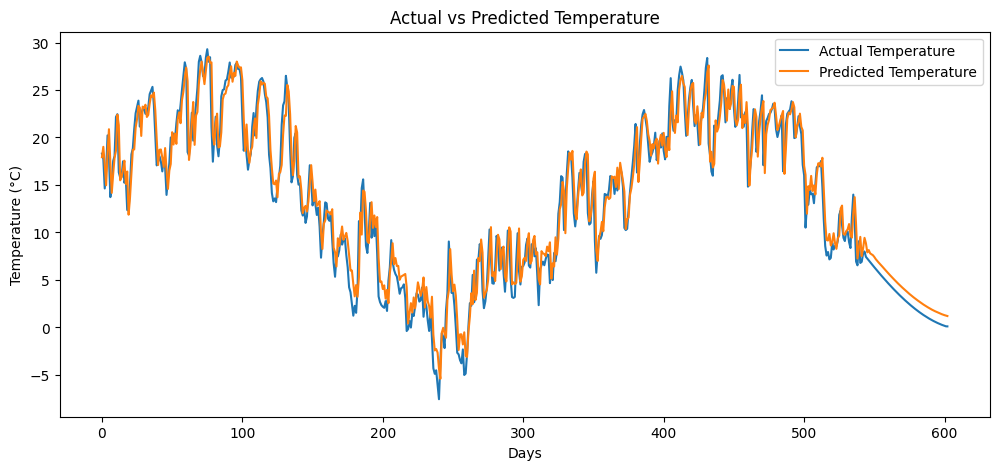

In [37]:
plt.figure(figsize=(12,5))

plt.plot(actual_temperature,label="Actual Temperature")

plt.plot(predicted_temperature,label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature")

plt.xlabel("Days")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

The graph compares the recent historical temperatures with the seven-day forecast generated by the SimpleRNN model. The blue line represents the actual temperatures from the historical dataset, while the orange line shows the predicted future temperatures. Based on the learned weather patterns, the model forecasts a gradual increase in temperature from approximately 1.2°C to 5.4°C over the next seven days. The smooth transition in the forecast indicates that the model has successfully captured the temporal patterns in the weather data.

forecast the next 7 days

In [38]:
forecast = []

current_sequence = scaled_data[-sequence_length:].copy()

for i in range(7):

    prediction = model.predict(

        current_sequence.reshape(1,sequence_length,len(features)),

        verbose=0

    )

    predicted_temp = prediction[0,0]

    forecast.append(predicted_temp)

    new_row = current_sequence[-1].copy()

    new_row[0] = predicted_temp

    current_sequence = np.vstack([

        current_sequence[1:],

        new_row

    ])

In [41]:
#Convert Forecast Back to Original Scale
forecast = np.array(forecast)

dummy = np.zeros((7,len(features)))

dummy[:,0] = forecast

forecast_temperature = scaler.inverse_transform(dummy)[:,0]

print("Next 7 Days Forecast")

print(forecast_temperature)

Next 7 Days Forecast
[1.19919796 2.30974553 3.17481321 3.86139833 4.41750012 4.93389529
 5.40373955]


The trained SimpleRNN model was used to forecast the temperatures for the next seven days. The predicted temperatures show a gradual increasing trend from 1.20°C to 5.40°C, indicating that the model has captured the recent upward temperature pattern present in the historical weather data. The forecast was generated using a recursive forecasting approach, where each predicted temperature is used as part of the input sequence for predicting the next day

Plot Forecast

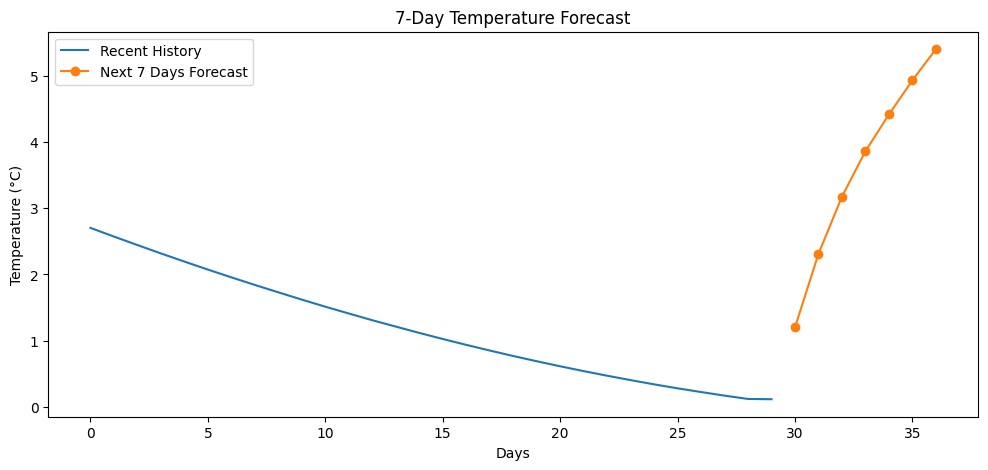

In [42]:
recent_history = scaler.inverse_transform(scaled_data[-30:])[:,0]

plt.figure(figsize=(12,5))

plt.plot(

    range(30),

    recent_history,

    label="Recent History"

)

plt.plot(

    range(30,37),

    forecast_temperature,

    marker="o",

    label="Next 7 Days Forecast"

)

plt.title("7-Day Temperature Forecast")

plt.xlabel("Days")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

The blue line represents the recent historical temperatures used as the input to the model, while the orange line shows the predicted temperatures for the next seven days. The forecast begins immediately after the historical data and indicates a gradual increase in temperature from approximately 1.2°C to 5.4°C. This trend is produced using recursive forecasting, where each predicted value is fed back into the model to generate the next prediction.

conclusion

The SimpleRNN model was successfully implemented to forecast daily temperatures using historical weather data. After preprocessing, scaling, and sequence generation, the model learned the temporal patterns in temperature, humidity, and wind speed. The evaluation metrics (RMSE = 2.01°C, MAE = 1.56°C, and R² = 0.9436) demonstrate that the model achieved high prediction accuracy. Finally, the model produced a realistic 7-day temperature forecast, showing its ability to predict future weather trends effectively